# EPSP ratio comparison with Markram et al. 1997 dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Markram et al. 1997"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
0,mrk97_01,L5TTPC,L5TTPC,SSC,rat,P14 - P16,2.0,5,5,10,4,0.9886,0.0400,2,Markram et al. 1997,Record digitized from paper.,0.056569
1,mrk97_02,L5TTPC,L5TTPC,SSC,rat,P14 - P16,5.0,5,5,10,4,1.0161,0.0727,5,Markram et al. 1997,Record digitized from paper.,0.162562
2,mrk97_03,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,5,5,10,4,1.2038,0.0644,9,Markram et al. 1997,Record digitized from paper.,0.193200
3,mrk97_04,L5TTPC,L5TTPC,SSC,rat,P14 - P16,20.0,5,5,10,4,1.3687,0.0909,11,Markram et al. 1997,Record digitized from paper.,0.301481
4,mrk97_05,L5TTPC,L5TTPC,SSC,rat,P14 - P16,30.0,5,5,10,4,1.4239,0.0745,3,Markram et al. 1997,Record digitized from paper.,0.129038
5,mrk97_06,L5TTPC,L5TTPC,SSC,rat,P14 - P16,40.0,5,5,10,4,1.5008,0.1200,4,Markram et al. 1997,Record digitized from paper.,0.240000
6,mrk97_07,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,10,5,10,4,1.2013,0.0626,6,Markram et al. 1997,Record digitized from paper. AP train repeated...,0.153338
7,mrk97_08,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,-10,5,10,4,0.7922,0.0259,6,Markram et al. 1997,Record digitized from paper. AP train repeated...,0.063442


In [2]:
# Load Markram 1997 data
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/markram_1997/L5TTPC_L5TTPC.csv')

No outliers in data/insilico/markram_1997/L5TTPC_L5TTPC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1431,160737,144433,30.0,50,0.881226,1.725978
445,145185,155180,50.0,-10,0.966552,2.653500
2817,152676,137887,10.0,50,0.629667,3.429046
4810,144144,142961,2.0,-50,1.004200,4.152858
2470,141511,137626,20.0,10,1.629596,0.911015


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.962318,0.116389,0.011639,100
1,2.0,-30,0.943111,0.133197,0.013320,100
2,2.0,-10,0.901727,0.156539,0.015654,100
3,2.0,5,0.987729,0.314079,0.031408,100
4,2.0,10,0.933250,0.312872,0.031287,100
5,2.0,30,0.915399,0.286644,0.028664,100
6,2.0,50,0.874544,0.246125,0.024612,100
7,5.0,-50,0.919176,0.169958,0.016996,100
8,5.0,-30,0.890221,0.188846,0.018885,100
9,5.0,-10,0.829130,0.214822,0.021482,100


t-test results for frequency_train = 2.000000: s = -0.017, p = 0.988
t-test results for frequency_train = 5.000000: s = -0.906, p = 0.399
t-test results for frequency_train = 10.000000: s = -0.608, p = 0.550
t-test results for frequency_train = 20.000000: s = 0.229, p = 0.821
t-test results for frequency_train = 30.000000: s = -0.080, p = 0.940
t-test results for frequency_train = 40.000000: s = -0.591, p = 0.586


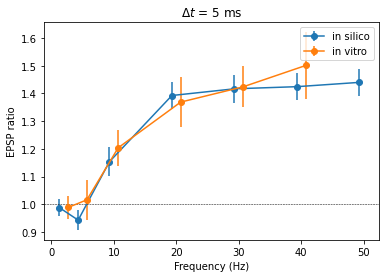

In [3]:
# Plot LTP freq
sel_invitro = invitro[invitro.dt_train==5]
sel_insilico = insilico[insilico.dt_train==5]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = 5 ms');
#fig.savefig('l5_l5_ltp.svg')

t-test results for frequency_train = 10.000000: s = 1.667, p = 0.103


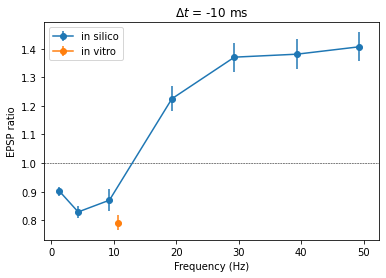

In [4]:
# Plot LTD freq
sel_invitro = invitro[invitro.dt_train==-10]
sel_insilico = insilico[insilico.dt_train==-10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = -10 ms');
#fig.savefig('l5_l5_ltd.svg')

t-test results for dt_train = -10.000000: s = 1.667, p = 0.103
t-test results for dt_train = 5.000000: s = -0.608, p = 0.550
t-test results for dt_train = 10.000000: s = -1.088, p = 0.299


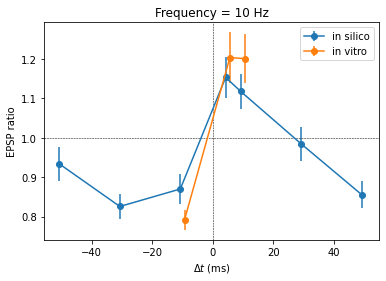

In [5]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==10]
sel_insilico = insilico[insilico.frequency_train==10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_title('Frequency = 10 Hz');
#fig.savefig('l5_l5_stdp10.svg')

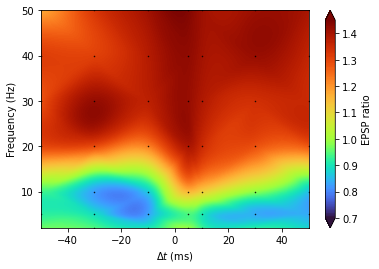

In [6]:
# Plot map
mapsize = np.array((6.2, 4.8))/3 if pubstyle else None
fig = plot_map(insilico, mapsize=mapsize)
#fig.savefig('l5_l5_map.svg')

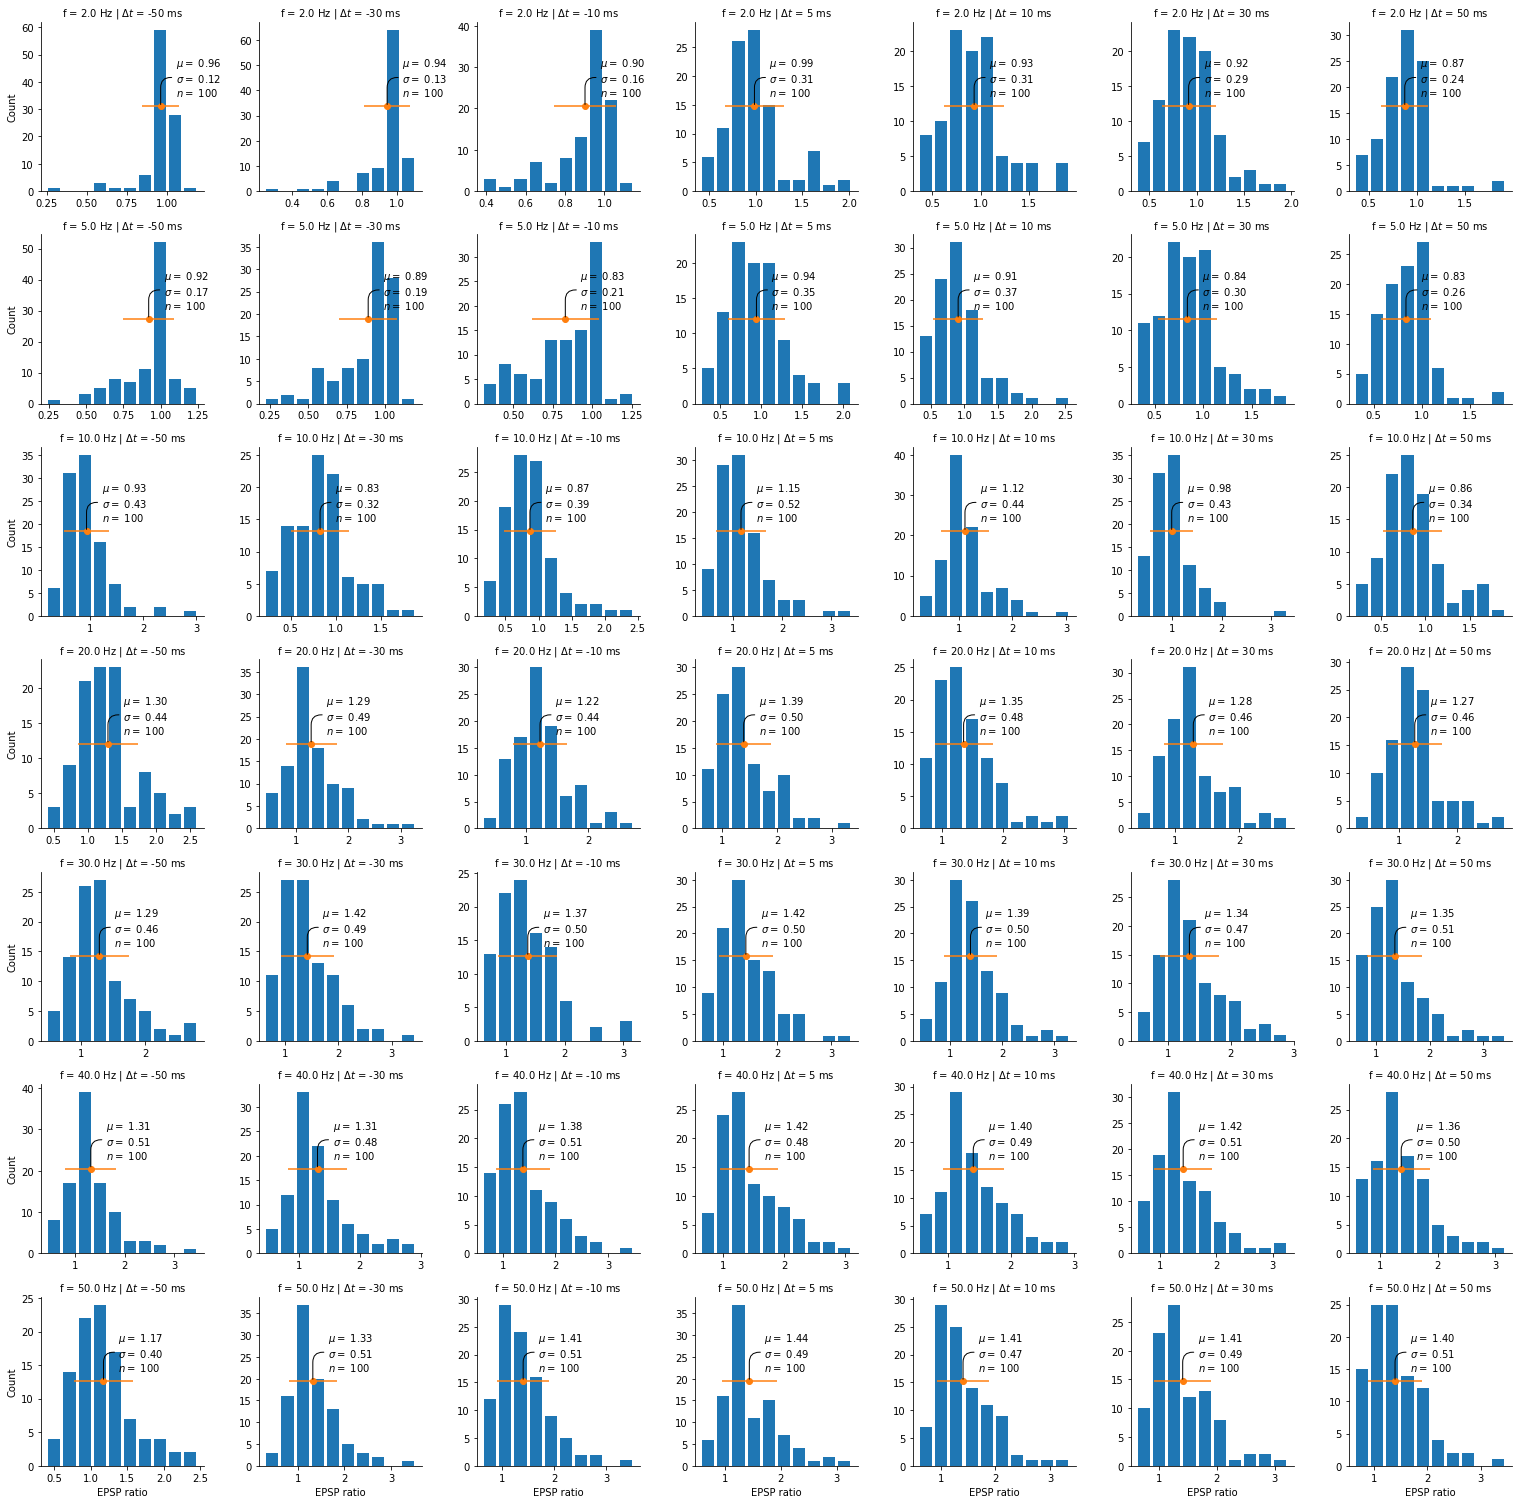

In [7]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l5_l5_mrk97_hist.png", dpi=300)

# Debug ttest

In [8]:
sel_invitro = invitro[invitro.dt_train==5]
sel_invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
0,mrk97_01,L5TTPC,L5TTPC,SSC,rat,P14 - P16,2.0,5,5,10,4,0.9886,0.0400,2,Markram et al. 1997,Record digitized from paper.,0.056569
1,mrk97_02,L5TTPC,L5TTPC,SSC,rat,P14 - P16,5.0,5,5,10,4,1.0161,0.0727,5,Markram et al. 1997,Record digitized from paper.,0.162562
2,mrk97_03,L5TTPC,L5TTPC,SSC,rat,P14 - P16,10.0,5,5,10,4,1.2038,0.0644,9,Markram et al. 1997,Record digitized from paper.,0.193200
3,mrk97_04,L5TTPC,L5TTPC,SSC,rat,P14 - P16,20.0,5,5,10,4,1.3687,0.0909,11,Markram et al. 1997,Record digitized from paper.,0.301481
4,mrk97_05,L5TTPC,L5TTPC,SSC,rat,P14 - P16,30.0,5,5,10,4,1.4239,0.0745,3,Markram et al. 1997,Record digitized from paper.,0.129038
5,mrk97_06,L5TTPC,L5TTPC,SSC,rat,P14 - P16,40.0,5,5,10,4,1.5008,0.1200,4,Markram et al. 1997,Record digitized from paper.,0.240000


In [9]:
sel_insilico = insilico[insilico.dt_train==5]
sel_insilico

,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
3,2.0,5,0.987729,0.314079,0.031408,100
10,5.0,5,0.942867,0.353813,0.035381,100
17,10.0,5,1.153493,0.519465,0.051947,100
24,20.0,5,1.392519,0.502623,0.050262,100
31,30.0,5,1.416697,0.499271,0.049927,100
38,40.0,5,1.424379,0.484397,0.048440,100
45,50.0,5,1.439930,0.496425,0.049642,100


In [10]:
b = sel_invitro.loc[4]
a = sel_insilico.loc[31]

stats.ttest_ind_from_stats(a.mean_epsp_ratio, a.std_epsp_ratio, a.sample_size,
                           b.mean_epsp_ratio, b.std_epsp_ratio, b.sample_size,
                           equal_var=False)

Ttest_indResult(statistic=-0.08031683744625953, pvalue=0.9396823609151481)